In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import re

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,mean_squared_error, r2_score, mean_absolute_error

import xgboost as xgb

from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential
from collections import Counter



In [2]:
data=pd.read_csv('/content/SolarPrediction.csv')
data.head()

,UNIXTime,Data,Time,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed,TimeSunRise,TimeSunSet
0,1475229326,9/29/2016 12:00:00 AM,23:55:26,1.21,48,30.46,59,177.39,5.62,06:13:00,18:13:00
1,1475229023,9/29/2016 12:00:00 AM,23:50:23,1.21,48,30.46,58,176.78,3.37,06:13:00,18:13:00
2,1475228726,9/29/2016 12:00:00 AM,23:45:26,1.23,48,30.46,57,158.75,3.37,06:13:00,18:13:00
3,1475228421,9/29/2016 12:00:00 AM,23:40:21,1.21,48,30.46,60,137.71,3.37,06:13:00,18:13:00
4,1475228124,9/29/2016 12:00:00 AM,23:35:24,1.17,48,30.46,62,104.95,5.62,06:13:00,18:13:00


In [3]:
df=data.copy()

In [4]:
df.shape

(32686, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   UNIXTime                32686 non-null  int64  
 1   Data                    32686 non-null  object 
 2   Time                    32686 non-null  object 
 3   Radiation               32686 non-null  float64
 4   Temperature             32686 non-null  int64  
 5   Pressure                32686 non-null  float64
 6   Humidity                32686 non-null  int64  
 7   WindDirection(Degrees)  32686 non-null  float64
 8   Speed                   32686 non-null  float64
 9   TimeSunRise             32686 non-null  object 
 10  TimeSunSet              32686 non-null  object 
dtypes: float64(4), int64(3), object(4)
memory usage: 2.7+ MB


In [6]:
df.describe()

,UNIXTime,Radiation,Temperature,Pressure,Humidity,WindDirection(Degrees),Speed
count,3.268600e+04,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000,32686.000000
mean,1.478047e+09,207.124697,51.103255,30.422879,75.016307,143.489821,6.243869
std,3.005037e+06,315.916387,6.201157,0.054673,25.990219,83.167500,3.490474
min,1.472724e+09,1.110000,34.000000,30.190000,8.000000,0.090000,0.000000
25%,1.475546e+09,1.230000,46.000000,30.400000,56.000000,82.227500,3.370000
50%,1.478026e+09,2.660000,50.000000,30.430000,85.000000,147.700000,5.620000
75%,1.480480e+09,354.235000,55.000000,30.460000,97.000000,179.310000,7.870000
max,1.483265e+09,1601.260000,71.000000,30.560000,103.000000,359.950000,40.500000


In [7]:
df['Data'] = df['Data'].apply(lambda x: x.split()[0])

In [8]:
df['Month'] = pd.to_datetime(df['Data']).dt.month
df['Day'] = pd.to_datetime(df['Data']).dt.day
df['Hour'] = pd.to_datetime(df['Time']).dt.hour
df['Minute'] = pd.to_datetime(df['Time']).dt.minute
df['Second'] = pd.to_datetime(df['Time']).dt.second

/tmp/ipykernel_10675/3244718825.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour
/tmp/ipykernel_10675/3244718825.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Minute'] = pd.to_datetime(df['Time']).dt.minute
/tmp/ipykernel_10675/3244718825.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Second'] = pd.to_datetime(df['Time']).dt.second


In [9]:
df['risehour'] = pd.to_datetime(df['TimeSunRise']).dt.hour
df['riseminute']=pd.to_datetime(df['TimeSunRise']).dt.minute

df['sethour'] = pd.to_datetime(df['TimeSunSet']).dt.hour
df['setminute'] = pd.to_datetime(df['TimeSunSet']).dt.minute

/tmp/ipykernel_10675/978559654.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['risehour'] = pd.to_datetime(df['TimeSunRise']).dt.hour
/tmp/ipykernel_10675/978559654.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['riseminute']=pd.to_datetime(df['TimeSunRise']).dt.minute
/tmp/ipykernel_10675/978559654.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['sethour'] = pd.to_datetime(df['TimeSunSet']).dt.hour
/tmp/ipykernel_10675/978559654.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensu

In [10]:

df.drop(['UNIXTime', 'Data', 'Time', 'TimeSunRise', 'TimeSunSet'], axis = 1, inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32686 entries, 0 to 32685
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Radiation               32686 non-null  float64
 1   Temperature             32686 non-null  int64  
 2   Pressure                32686 non-null  float64
 3   Humidity                32686 non-null  int64  
 4   WindDirection(Degrees)  32686 non-null  float64
 5   Speed                   32686 non-null  float64
 6   Month                   32686 non-null  int32  
 7   Day                     32686 non-null  int32  
 8   Hour                    32686 non-null  int32  
 9   Minute                  32686 non-null  int32  
 10  Second                  32686 non-null  int32  
 11  risehour                32686 non-null  int32  
 12  riseminute              32686 non-null  int32  
 13  sethour                 32686 non-null  int32  
 14  setminute               32686 non-null

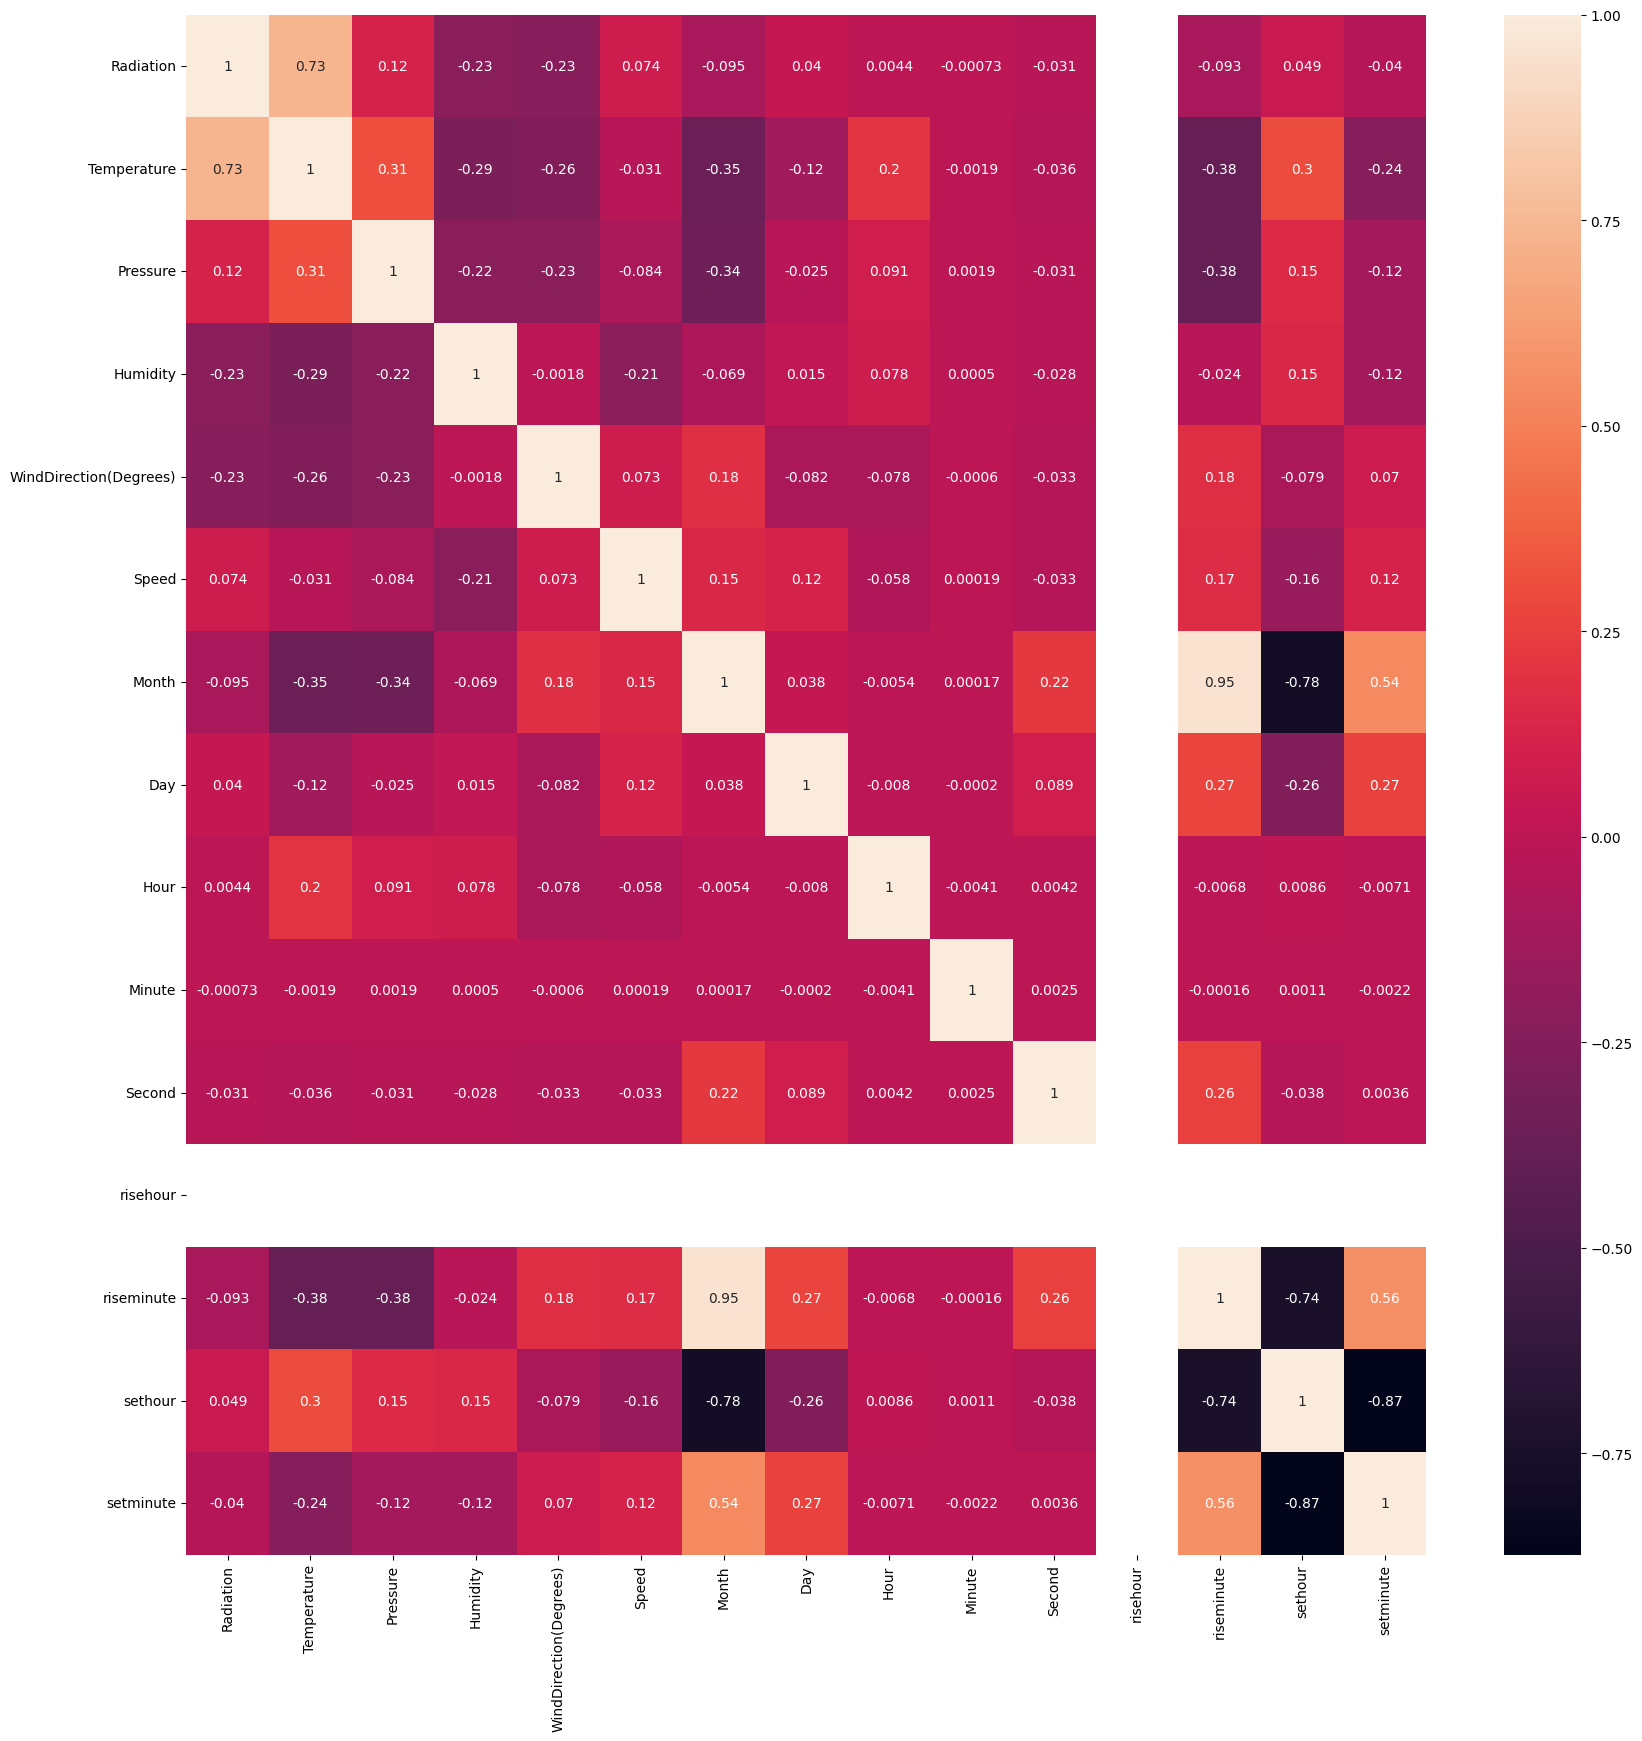

In [12]:
corr_matrix = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [13]:
X = df.drop(['Radiation'], axis=1)
y = df['Radiation']

In [14]:
bestfeatures = SelectKBest(score_func = chi2, k=5)

In [15]:
y_train100 =  df['Radiation'].apply(lambda x : int(x*100))

In [16]:
scaled_X = MinMaxScaler().fit_transform(X)

In [17]:
fit = bestfeatures.fit(scaled_X, y_train100)

In [18]:
scores = pd.DataFrame(fit.scores_)
column = pd.DataFrame(X.columns)

featureScores = pd.concat([column, scores], axis=1)
featureScores.columns = ['Features', 'feature_imp']

featureScores

,Features,feature_imp
0,Temperature,1651.685632
1,Pressure,523.791060
2,Humidity,1588.087433
3,WindDirection(Degrees),3271.827277
4,Speed,765.859779
5,Month,4684.579610
6,Day,2841.926850
7,Hour,691.185393
8,Minute,2702.449333
9,Second,2288.673032


In [19]:
featureScores.sort_values(by = 'feature_imp', ascending=False, inplace=True)
featureScores

,Features,feature_imp
12,sethour,12207.531454
5,Month,4684.579610
11,riseminute,4015.062771
3,WindDirection(Degrees),3271.827277
6,Day,2841.926850
8,Minute,2702.449333
9,Second,2288.673032
13,setminute,1863.712087
0,Temperature,1651.685632
2,Humidity,1588.087433


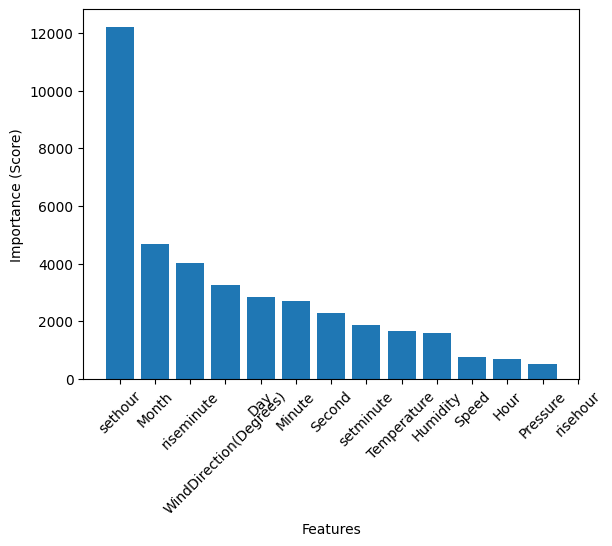

In [20]:
plt.bar(featureScores.Features, featureScores.feature_imp)
plt.xlabel("Features")
plt.ylabel("Importance (Score)")
plt.xticks(rotation=45)
plt.show()

In [21]:
from sklearn.ensemble import ExtraTreesRegressor
model_etc = ExtraTreesRegressor(n_estimators=5, verbose = 2)

In [22]:
model_etc.fit(scaled_X, y_train100)

building tree 1 of 5
building tree 2 of 5
building tree 3 of 5
building tree 4 of 5
building tree 5 of 5


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    1.2s finished


ExtraTreesRegressor(n_estimators=5, verbose=2)

In [23]:
importances_etc = pd.DataFrame(model_etc.feature_importances_)
columns_etc = pd.DataFrame(X.columns)

df_etc = pd.concat([columns_etc, importances_etc], axis=1)
df_etc.columns = ['Features', 'feature_imp']

In [24]:
df_etc.sort_values(by = 'feature_imp', ascending=False, inplace=True)
df_etc

,Features,feature_imp
7,Hour,0.378341
0,Temperature,0.364861
3,WindDirection(Degrees),0.064963
2,Humidity,0.064263
6,Day,0.028780
1,Pressure,0.014608
8,Minute,0.013822
12,sethour,0.013696
11,riseminute,0.013657
13,setminute,0.011313


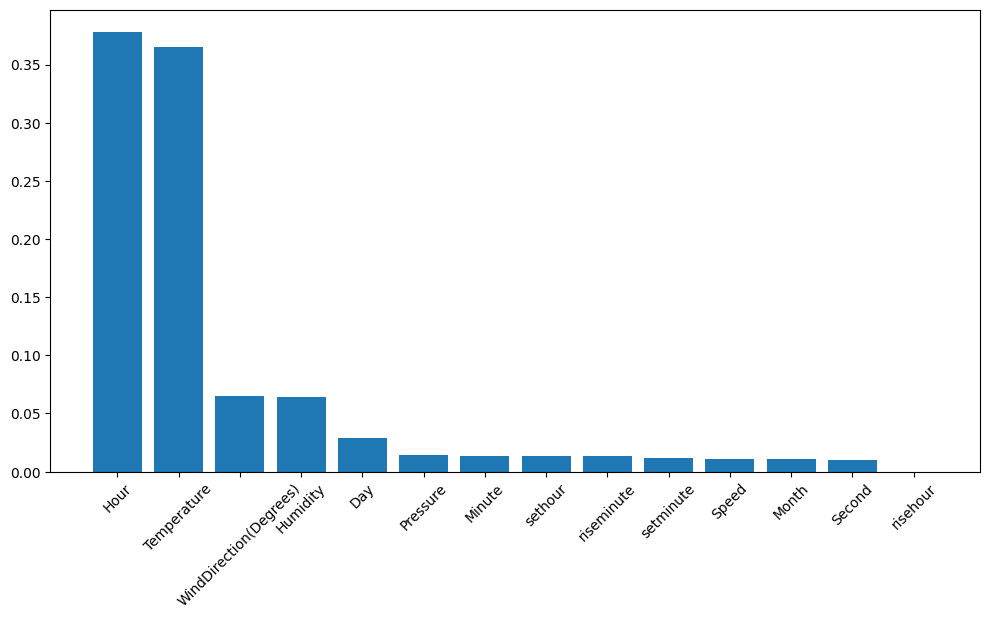

In [25]:
plt.figure(figsize=(12,6))
plt.bar(x=df_etc['Features'], height=df_etc['feature_imp'])
plt.xticks(rotation=45)
plt.show()

In [26]:
X = df.drop(['Radiation'], axis=1)
y = df['Radiation']

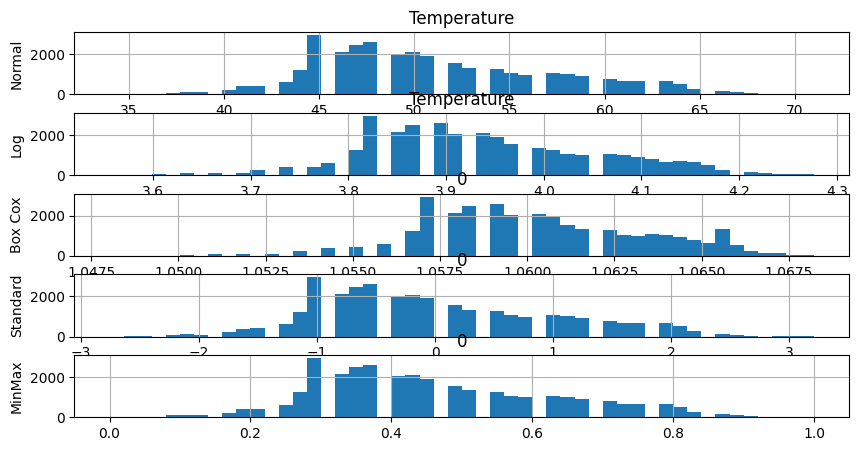

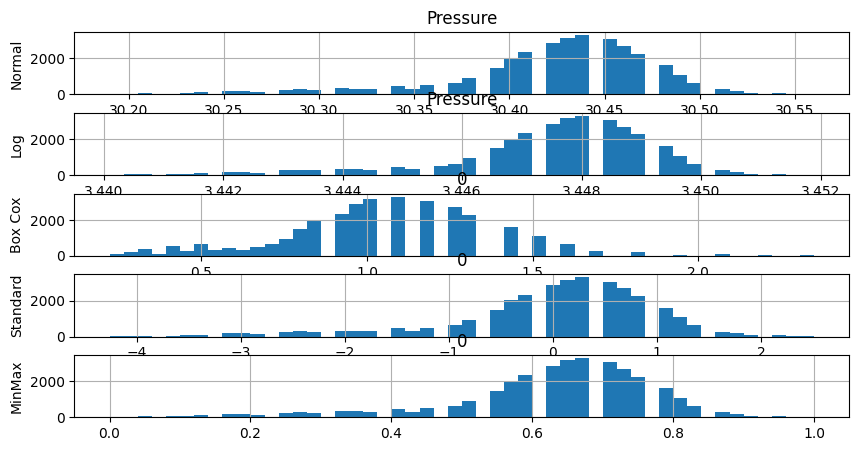

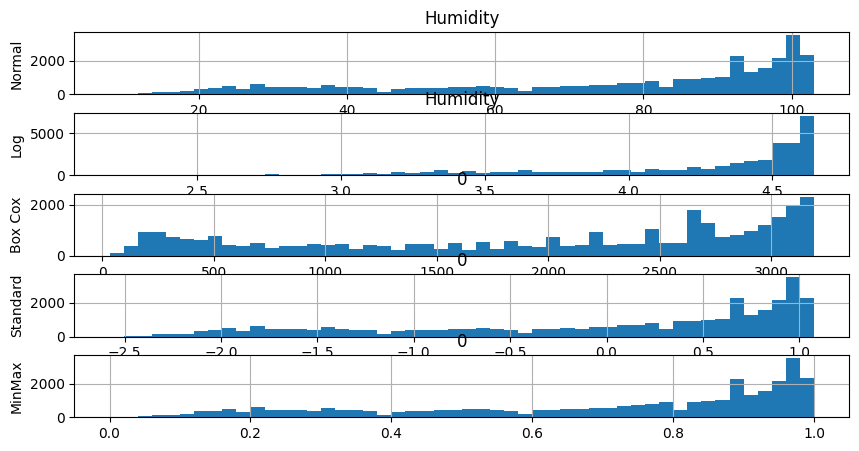

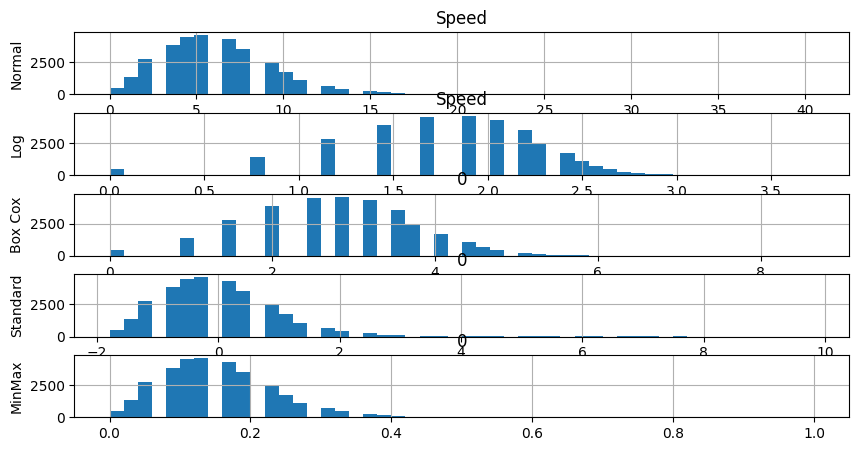

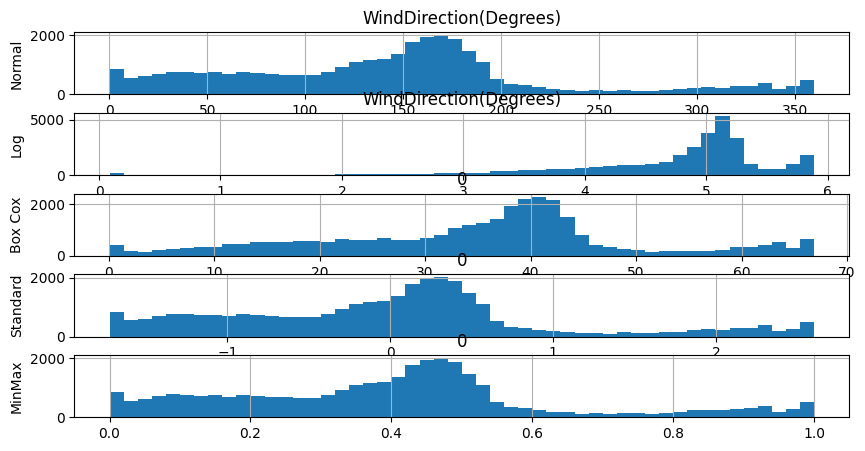

In [27]:
features_to_transform = ['Temperature', 'Pressure', 'Humidity', 'Speed', 'WindDirection(Degrees)']
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

# What are we doing here?
# looking at plots of T,P,Humidity, Wind using BoxCox, Log, Min-Max & Standard transformation
# Whichever plot looks like a normal distribution curve is preferred for applying in models

for i in features_to_transform:
    # Create a figure with 5 vertical subplots
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 5))

    pd.DataFrame(X[i]).hist(ax = ax1, bins = 50)

    pd.DataFrame(np.log(X[i] + 1)).hist(ax=ax2, bins=50)

    # Box-Cox transformation
    # data_shifted = X[i] + 1
    pd.DataFrame(stats.boxcox(X[i]+1)[0]).hist(ax = ax3, bins = 50)

    # StandardScaler transformation histogram
    scaled_data_standard = standard_scaler.fit_transform(X[[i]])
    pd.DataFrame(scaled_data_standard).hist(ax=ax4, bins=50)


    # MinMaxScaler transformation histogram
    scaled_data_minmax = min_max_scaler.fit_transform(X[[i]])
    pd.DataFrame(scaled_data_minmax).hist(ax=ax5, bins=50)

    ax1.set_ylabel('Normal')
    ax2.set_ylabel('Log')
    ax3.set_ylabel('Box Cox')
    ax4.set_ylabel('Standard')
    ax5.set_ylabel('MinMax')


In [28]:
transform = {
    'Temperature': np.log(X['Temperature'] + 1),
    'Pressure': X['Pressure'], # Removed problematic stats.boxcox transformation
    'Humidity': stats.boxcox(X['Humidity']+1)[0],
    'Speed': np.log(X['Speed'] + 1),
    'WindDirection(Degrees)': min_max_scaler.fit_transform(X[['WindDirection(Degrees)']])}

In [29]:
for i in transform:
    X[i]=transform[i]

In [30]:
from sklearn.model_selection import train_test_split

# X we are using is the changed one
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# here we don't use fit for X_test as

In [31]:
X_train.shape, X_test.shape

((26148, 14), (6538, 14))

In [32]:
from xgboost import XGBRegressor


model_xgb = XGBRegressor(learning_rate=0.1,
    max_depth=8,
    n_estimators=100,
    random_state=42)

In [33]:
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
y_prediction = model_xgb.predict(X_test)

In [35]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
r2 = r2_score(y_test, y_prediction)
mae = mean_absolute_error(y_test, y_prediction)

print("Testing performance")

print("RMSE: {:.2f}".format(rmse))
print("R2: {:.2f}".format(r2))
print("MAE: {:.2f}".format(mae))

Testing performance
RMSE: 82.68
R2: 0.93
MAE: 33.44


In [36]:
import keras
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
model = None
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=X_train.shape[1])) #input_dim = n_columns
model.add(Dropout(0.33))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.33))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.33))

model.add(Dense(1, activation='linear'))

# compiling all
model.compile(metrics= ['mse'], loss='mae', optimizer= Adam(learning_rate=0.00005))
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [39]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=32)

Epoch 1/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 205.8633 - mse: 141647.2812 - val_loss: 219.1199 - val_mse: 151214.9531
Epoch 2/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 204.2982 - mse: 139531.1250 - val_loss: 216.8403 - val_mse: 147469.1250
Epoch 3/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 198.8344 - mse: 131115.0938 - val_loss: 205.2672 - val_mse: 130416.2734
Epoch 4/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 180.5990 - mse: 105259.3516 - val_loss: 175.4238 - val_mse: 93214.1953
Epoch 5/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 148.2584 - mse: 68300.5625 - val_loss: 137.6903 - val_mse: 55816.1367
Epoch 6/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 125.3138 - mse: 48609.4961 - val_loss: 120.1169 - val_mse: 44635.2500
Epoch 7/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 116.1543 - mse: 43516.4766 - val_loss: 112.6669 - val_mse: 40677.0742
Epoch 8/50
736/736 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 112.1986 - mse: 41743.9

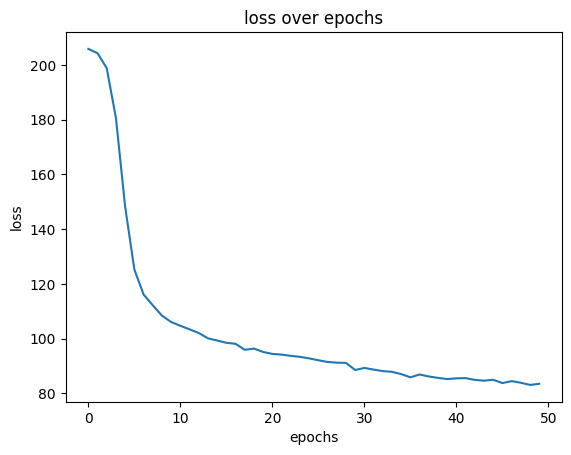

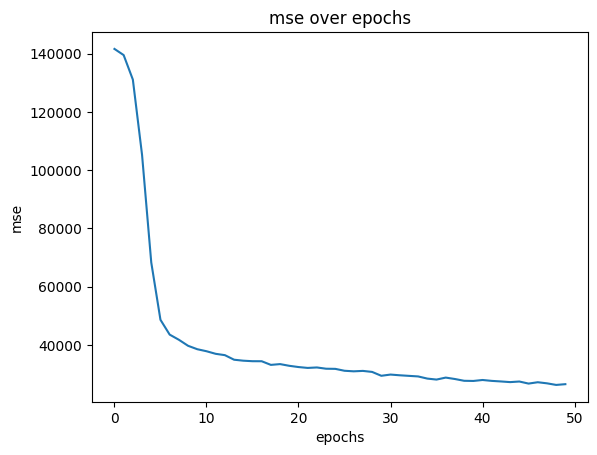

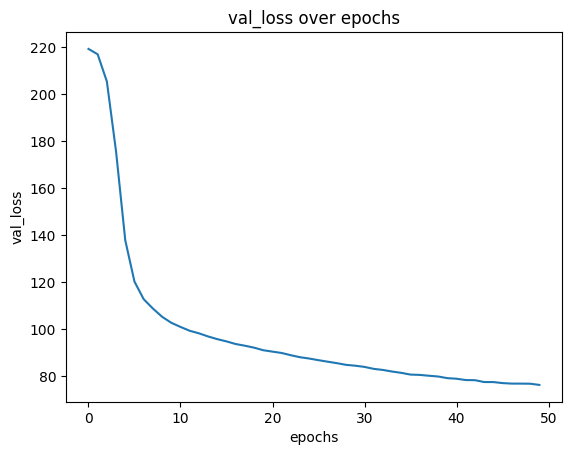

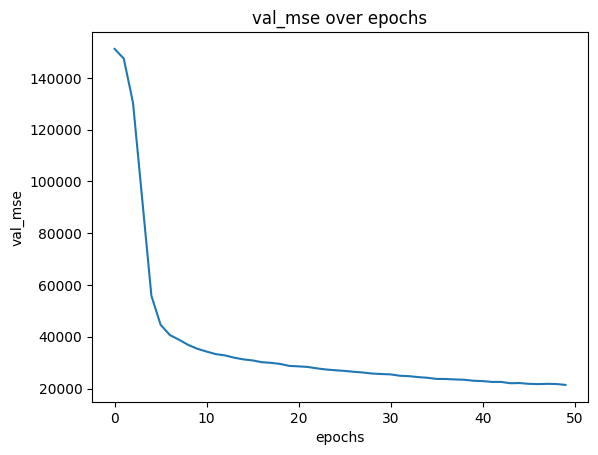

In [40]:
fit = history.history
for i in fit:
    plt.plot(fit[i])
    plt.title(i + ' over epochs')
    plt.ylabel(i)
    plt.xlabel('epochs')
    plt.show()

In [41]:
y_prediction_mlp =model.predict(X_test)

205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [42]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rmse_mlp = np.sqrt(mean_squared_error(y_test, y_prediction_mlp))
r2_mlp = r2_score(y_test, y_prediction_mlp)
mae_mlp = mean_absolute_error(y_test, y_prediction_mlp)


print("Testing performance")

print("RMSE: {:.2f}".format(rmse_mlp))
print("R2: {:.2f}".format(r2_mlp))
print("MAE: {:.2f}".format(mae_mlp))

Testing performance
RMSE: 140.21
R2: 0.80
MAE: 70.46
